# IA Générative — Classification par LLM (DeepSeek-R1)

Ce notebook utilise un **modèle d'IA générative** (DeepSeek-R1 8B) via Ollama
pour la classification de sentiment en mode **zero-shot** et **few-shot**,
ainsi que l'**analyse d'aspects** (ABSA).

**Sujet PDF** : Section B3 — IA Générative

### Approches testées
1. **Zero-shot** : prédire la polarité sans exemples dans le prompt
2. **Few-shot** : prédire la polarité avec quelques exemples dans le prompt
3. **ABSA** : identifier les aspects mentionnés et leur sentiment

### Stack
- **Modèle** : DeepSeek-R1 8B (raisonnement)
- **Runtime** : Ollama (inférence locale)
- **API** : REST (`http://localhost:11434`)

## 0. Imports et Configuration

In [ ]:
import sys
sys.path.insert(0, '../..')

import os
import re
import time
import requests
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from src.constants import RANDOM_STATE, POLARITY_NAMES, stars_to_polarity
from src.data_utils import load_parquet
from src.visualization import setup_plot_style, save_figure

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

setup_plot_style()

# Configuration
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "deepseek-r1:8b"
SAMPLE_SIZE = 60   # 20 par classe de polarité

In [2]:
# Vérifier la connexion à Ollama
try:
    r = requests.get("http://localhost:11434/api/tags", timeout=5)
    models = [m['name'] for m in r.json().get('models', [])]
    print(f"Ollama connecté — Modèles : {models}")
    assert MODEL_NAME in models, f"{MODEL_NAME} non trouvé ! Exécutez : ollama pull {MODEL_NAME}"
    print(f"Modèle {MODEL_NAME} prêt.")
except requests.ConnectionError:
    raise RuntimeError("Ollama n'est pas lancé ! Exécutez : ollama serve")

Ollama connecté — Modèles : ['deepseek-r1:8b']
Modèle deepseek-r1:8b prêt.


---
## 1. Chargement des Données

Échantillon stratifié de 60 avis (20 par classe de polarité) pour une évaluation
équilibrée et rapide.

In [ ]:
df = load_parquet('reviews_clean.parquet', base_path='../../data/cleaned', columns=['text', 'stars'])
df = df.dropna(subset=['text', 'stars'])
df['polarity'] = df['stars'].apply(stars_to_polarity)

# Échantillon stratifié : 20 avis par classe
samples = []
for pol_class in [0, 1, 2]:
    subset = df[df['polarity'] == pol_class].sample(n=20, random_state=RANDOM_STATE)
    samples.append(subset)
df_sample = pd.concat(samples).reset_index(drop=True)

print(f"Échantillon : {len(df_sample)} avis")
print(f"Distribution :")
for i, name in enumerate(POLARITY_NAMES):
    n = (df_sample['polarity'] == i).sum()
    print(f"  {name}: {n}")

---
## 2. Fonctions Utilitaires

DeepSeek-R1 utilise des blocs `<think>...</think>` pour son raisonnement interne.
On les supprime pour extraire la réponse finale.

In [4]:
def query_ollama(prompt, temperature=0.1, max_tokens=512):
    '''Envoie un prompt à DeepSeek-R1 via Ollama.'''
    payload = {
        "model": MODEL_NAME,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": temperature,
            "num_predict": max_tokens,
        }
    }
    response = requests.post(OLLAMA_URL, json=payload, timeout=180)
    response.raise_for_status()
    return response.json()["response"]


def parse_response(response):
    '''Supprime les blocs <think>...</think> de DeepSeek-R1.'''
    return re.sub(r'<think>.*?</think>', '', response, flags=re.DOTALL).strip()


def extract_sentiment(response):
    '''Extrait le label de sentiment (0=Négatif, 1=Neutre, 2=Positif, -1=inconnu).'''
    text = parse_response(response).lower()
    if any(w in text for w in ['positive', 'positif']):
        return 2
    elif any(w in text for w in ['negative', 'négatif', 'negatif', 'négative']):
        return 0
    elif any(w in text for w in ['neutral', 'neutre']):
        return 1
    return -1


def classify_batch(texts, prompt_fn, desc="Classification"):
    '''Classifie un lot de textes avec une fonction de prompt.'''
    predictions = []
    durations = []
    raw_responses = []

    for text in tqdm(texts, desc=desc):
        prompt = prompt_fn(text)
        start = time.time()
        try:
            response = query_ollama(prompt)
        except Exception as e:
            print(f"\nErreur: {e}")
            response = ""
        elapsed = time.time() - start

        pred = extract_sentiment(response)
        predictions.append(pred)
        durations.append(elapsed)
        raw_responses.append(response)

    return predictions, durations, raw_responses


# Test rapide
resp = query_ollama("Say hello in one word.", max_tokens=64)
print(f"Test Ollama : {parse_response(resp)}")

Test Ollama : 


---
## 3. Classification Zero-shot

Le modèle doit prédire le sentiment **sans aucun exemple** dans le prompt.
C'est le test le plus difficile : il repose uniquement sur les connaissances
pré-entraînées du LLM.

In [5]:
ZERO_SHOT_TEMPLATE = (
    "Classify the sentiment of this customer review as exactly one of: "
    "positive, neutral, or negative.\n\n"
    "Reply with ONLY one word: positive, neutral, or negative.\n\n"
    'Review: "{text}"\n\n'
    "Sentiment:"
)

def zero_shot_prompt(text):
    truncated = text[:500] if len(text) > 500 else text
    return ZERO_SHOT_TEMPLATE.format(text=truncated)

# Exemple de prompt
print("Exemple de prompt zero-shot :\n")
print(zero_shot_prompt("The food was great but the service was slow."))

Exemple de prompt zero-shot :

Classify the sentiment of this customer review as exactly one of: positive, neutral, or negative.

Reply with ONLY one word: positive, neutral, or negative.

Review: "The food was great but the service was slow."

Sentiment:


In [6]:
print("=== CLASSIFICATION ZERO-SHOT ===")
print(f"Modèle : {MODEL_NAME}")
print(f"Échantillon : {len(df_sample)} avis\n")

texts = df_sample['text'].tolist()
y_true = df_sample['polarity'].values

start_time = time.time()
preds_zs, times_zs, raw_zs = classify_batch(texts, zero_shot_prompt, desc="Zero-shot")
total_time_zs = time.time() - start_time

preds_zs = np.array(preds_zs)
n_invalid_zs = (preds_zs == -1).sum()
print(f"\nTemps total : {total_time_zs:.0f}s ({total_time_zs/len(texts):.1f}s/avis)")
print(f"Réponses non reconnues : {n_invalid_zs}/{len(texts)}")

=== CLASSIFICATION ZERO-SHOT ===
Modèle : deepseek-r1:8b
Échantillon : 60 avis



Zero-shot:   0%|          | 0/60 [00:00<?, ?it/s]

Zero-shot:   2%|▏         | 1/60 [00:14<13:47, 14.03s/it]

Zero-shot:   3%|▎         | 2/60 [00:34<16:56, 17.53s/it]

Zero-shot:   5%|▌         | 3/60 [00:51<16:43, 17.60s/it]

...

Zero-shot:  97%|█████████▋| 58/60 [21:19<00:47, 23.85s/it]

Zero-shot:  98%|█████████▊| 59/60 [21:38<00:22, 22.30s/it]

Zero-shot: 100%|██████████| 60/60 [22:04<00:00, 23.66s/it]

Zero-shot: 100%|██████████| 60/60 [22:04<00:00, 22.08s/it]


Temps total : 1325s (22.1s/avis)
Réponses non reconnues : 0/60


=== RÉSULTATS ZERO-SHOT ===
Accuracy  : 0.6833
F1 Macro  : 0.5732
Valides   : 60/60

              precision    recall  f1-score   support

     Négatif       0.61      1.00      0.75        20
      Neutre       1.00      0.05      0.10        20
     Positif       0.77      1.00      0.87        20

    accuracy                           0.68        60
   macro avg       0.79      0.68      0.57        60
weighted avg       0.79      0.68      0.57        60



Figure saved to: ../../outputs/figures/ia_gen_zeroshot_confusion.png


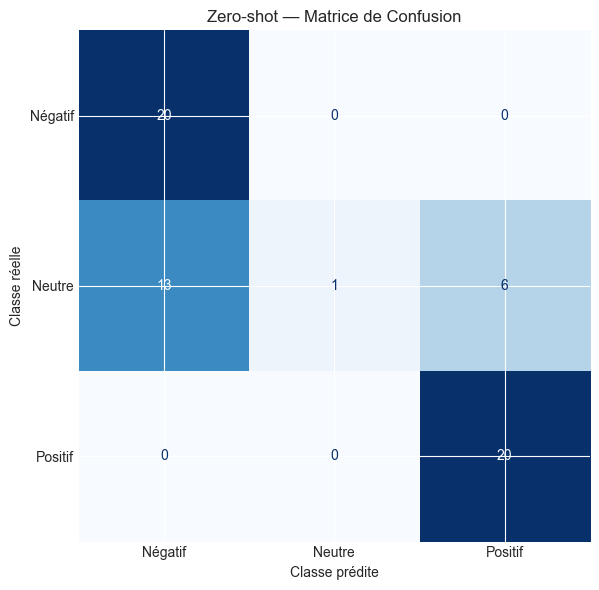

In [7]:
# Évaluer les prédictions valides
valid_zs = preds_zs != -1
y_true_zs = y_true[valid_zs]
preds_zs_v = preds_zs[valid_zs]

if valid_zs.sum() == 0:
    print("ERREUR : aucune prédiction valide ! Vérifiez le format de réponse.")
    print("Exemples de réponses brutes :")
    for r in raw_zs[:3]:
        print(f"  {repr(r[:200])}")
    acc_zs, f1_zs = 0.0, 0.0
else:
    acc_zs = accuracy_score(y_true_zs, preds_zs_v)
    f1_zs = f1_score(y_true_zs, preds_zs_v, average='macro', zero_division=0)

    print("=== RÉSULTATS ZERO-SHOT ===")
    print(f"Accuracy  : {acc_zs:.4f}")
    print(f"F1 Macro  : {f1_zs:.4f}")
    print(f"Valides   : {valid_zs.sum()}/{len(preds_zs)}")
    print()
    print(classification_report(y_true_zs, preds_zs_v, target_names=POLARITY_NAMES, zero_division=0))

    # Matrice de confusion
    fig, ax = plt.subplots(figsize=(7, 6))
    cm = confusion_matrix(y_true_zs, preds_zs_v, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(cm, display_labels=POLARITY_NAMES)
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title('Zero-shot — Matrice de Confusion')
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')
    plt.tight_layout()
    save_figure('ia_gen_zeroshot_confusion.png', output_dir='../../outputs/figures')
    plt.show()

---
## 4. Classification Few-shot (3 exemples)

On fournit **3 exemples annotés** (un par classe) dans le prompt pour guider le modèle.
Cette approche devrait améliorer les performances en calibrant le format de réponse.

In [8]:
FEW_SHOT_TEMPLATE = (
    "You are a sentiment classifier for customer reviews.\n\n"
    "Here are some examples:\n\n"
    'Review: "Absolutely amazing! The food was delicious, the staff was incredibly '
    'friendly, and the atmosphere was perfect. Will definitely come back!"\n'
    "Sentiment: positive\n\n"
    'Review: "It was okay. The food was decent but nothing memorable. '
    'Service was average."\n'
    "Sentiment: neutral\n\n"
    'Review: "Worst experience ever. The food was cold, the waiter was rude, '
    'and we waited over an hour. Complete waste of money."\n'
    "Sentiment: negative\n\n"
    "Now classify this review with exactly one word (positive, neutral, or negative):\n\n"
    'Review: "{text}"\n\n'
    "Sentiment:"
)

def few_shot_prompt(text):
    truncated = text[:500] if len(text) > 500 else text
    return FEW_SHOT_TEMPLATE.format(text=truncated)

print("=== CLASSIFICATION FEW-SHOT (3 exemples) ===")
print(f"Modèle : {MODEL_NAME}\n")

start_time = time.time()
preds_fs, times_fs, raw_fs = classify_batch(texts, few_shot_prompt, desc="Few-shot")
total_time_fs = time.time() - start_time

preds_fs = np.array(preds_fs)
n_invalid_fs = (preds_fs == -1).sum()
print(f"\nTemps total : {total_time_fs:.0f}s ({total_time_fs/len(texts):.1f}s/avis)")
print(f"Réponses non reconnues : {n_invalid_fs}/{len(texts)}")

=== CLASSIFICATION FEW-SHOT (3 exemples) ===
Modèle : deepseek-r1:8b



Few-shot:   0%|          | 0/60 [00:00<?, ?it/s]

Few-shot:   2%|▏         | 1/60 [00:30<29:39, 30.16s/it]

Few-shot:   3%|▎         | 2/60 [00:59<28:55, 29.92s/it]

Few-shot:   5%|▌         | 3/60 [01:20<24:32, 25.84s/it]

...

Few-shot:  97%|█████████▋| 58/60 [25:14<00:46, 23.06s/it]

Few-shot:  98%|█████████▊| 59/60 [25:46<00:25, 25.77s/it]

Few-shot: 100%|██████████| 60/60 [26:09<00:00, 25.13s/it]

Few-shot: 100%|██████████| 60/60 [26:09<00:00, 26.16s/it]


Temps total : 1570s (26.2s/avis)
Réponses non reconnues : 2/60


=== RÉSULTATS FEW-SHOT ===
Accuracy  : 0.6724
F1 Macro  : 0.5887
Valides   : 58/60

              precision    recall  f1-score   support

     Négatif       0.67      0.90      0.77        20
      Neutre       0.40      0.11      0.17        18
     Positif       0.73      0.95      0.83        20

    accuracy                           0.67        58
   macro avg       0.60      0.65      0.59        58
weighted avg       0.61      0.67      0.60        58



Figure saved to: ../../outputs/figures/ia_gen_fewshot_confusion.png


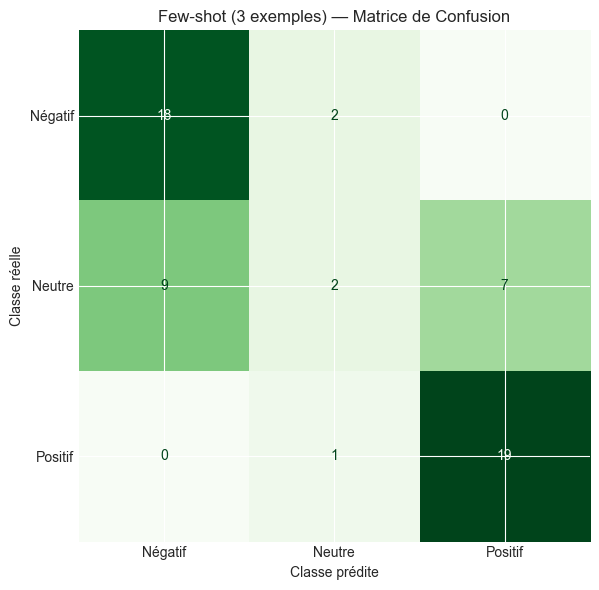

In [9]:
valid_fs = preds_fs != -1
y_true_fs = y_true[valid_fs]
preds_fs_v = preds_fs[valid_fs]

if valid_fs.sum() == 0:
    print("ERREUR : aucune prédiction valide !")
    for r in raw_fs[:3]:
        print(f"  {repr(r[:200])}")
    acc_fs, f1_fs = 0.0, 0.0
else:
    acc_fs = accuracy_score(y_true_fs, preds_fs_v)
    f1_fs = f1_score(y_true_fs, preds_fs_v, average='macro', zero_division=0)

    print("=== RÉSULTATS FEW-SHOT ===")
    print(f"Accuracy  : {acc_fs:.4f}")
    print(f"F1 Macro  : {f1_fs:.4f}")
    print(f"Valides   : {valid_fs.sum()}/{len(preds_fs)}")
    print()
    print(classification_report(y_true_fs, preds_fs_v, target_names=POLARITY_NAMES, zero_division=0))

    # Matrice de confusion
    fig, ax = plt.subplots(figsize=(7, 6))
    cm_fs = confusion_matrix(y_true_fs, preds_fs_v, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(cm_fs, display_labels=POLARITY_NAMES)
    disp.plot(cmap='Greens', ax=ax, colorbar=False)
    ax.set_title('Few-shot (3 exemples) — Matrice de Confusion')
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')
    plt.tight_layout()
    save_figure('ia_gen_fewshot_confusion.png', output_dir='../../outputs/figures')
    plt.show()

In [10]:
# Comparaison Zero-shot vs Few-shot
print("=== COMPARAISON ZERO-SHOT vs FEW-SHOT ===\n")
comp_zf = pd.DataFrame({
    'Approche': ['Zero-shot', 'Few-shot (3 ex.)'],
    'Accuracy': [acc_zs, acc_fs],
    'F1 Macro': [f1_zs, f1_fs],
    'Temps total (s)': [total_time_zs, total_time_fs],
    'Temps/avis (s)': [total_time_zs / len(texts), total_time_fs / len(texts)],
})
display(comp_zf.style.format({
    'Accuracy': '{:.4f}', 'F1 Macro': '{:.4f}',
    'Temps total (s)': '{:.0f}', 'Temps/avis (s)': '{:.1f}'
}).highlight_max(subset=['F1 Macro'], color='lightgreen'))

delta_f1 = f1_fs - f1_zs
print(f"\nGain few-shot vs zero-shot : {delta_f1:+.4f} F1")

=== COMPARAISON ZERO-SHOT vs FEW-SHOT ===



,Approche,Accuracy,F1 Macro,Temps total (s),Temps/avis (s)
0,Zero-shot,0.6833,0.5732,1325,22.1
1,Few-shot (3 ex.),0.6724,0.5887,1570,26.2



Gain few-shot vs zero-shot : +0.0155 F1


---
## 5. Analyse d'Aspects (ABSA)

L'**Aspect-Based Sentiment Analysis** identifie les aspects mentionnés dans un avis
(nourriture, service, ambiance, prix…) et détermine le sentiment associé à chacun.

C'est un cas d'usage où les LLM excellent : la tâche est trop complexe pour un
classifieur supervisé simple, mais naturelle pour un modèle de langage.

In [11]:
ABSA_TEMPLATE = (
    "Analyze the following restaurant/business review. "
    "Identify each aspect mentioned (e.g., food, service, ambiance, price, "
    "cleanliness, location, wait time) and determine the sentiment for each.\n\n"
    'Review: "{text}"\n\n'
    "List each aspect with its sentiment:\n"
    "- [aspect]: [positive/neutral/negative] — [brief justification]"
)

# Sélectionner 5 avis longs et variés (au moins un par classe)
df_long = df_sample[df_sample['text'].str.len() > 150].copy()
if len(df_long) > 5:
    long_samples = []
    for pol_class in [0, 1, 2]:
        subset = df_long[df_long['polarity'] == pol_class]
        long_samples.append(subset.sample(n=min(2, len(subset)), random_state=RANDOM_STATE))
    df_long = pd.concat(long_samples).head(5)

print(f"=== ASPECT-BASED SENTIMENT ANALYSIS (ABSA) ===")
print(f"Analyse de {len(df_long)} avis détaillés\n")

absa_results = []
for i, (_, row) in enumerate(df_long.iterrows()):
    text = row['text'][:800]
    stars = int(row['stars'])

    print(f"{'=' * 60}")
    print(f"AVIS #{i+1} — {stars} étoiles ({POLARITY_NAMES[row['polarity']]})")
    print(f"{'=' * 60}")
    print(f"Texte : {text[:250]}{'...' if len(text) > 250 else ''}\n")

    prompt = ABSA_TEMPLATE.format(text=text)
    response = query_ollama(prompt, temperature=0.2, max_tokens=512)
    cleaned = parse_response(response)

    print(f"Analyse LLM :")
    print(cleaned)
    print()
    absa_results.append({'stars': stars, 'polarity': row['polarity'], 'analysis': cleaned})

=== ASPECT-BASED SENTIMENT ANALYSIS (ABSA) ===
Analyse de 5 avis détaillés

AVIS #1 — 1 étoiles (Négatif)
Texte : Third time and last time here. The food literary took 2.5 hours to bring to our table. The gandules rice was cold and salty and the carnitas (pork meat) were over cook. Our waitress was pleasant but failed to come back to our table to fill our bevera...



Analyse LLM :


AVIS #2 — 2 étoiles (Négatif)
Texte : Since we moved to Arizona we haven't found good Italian. I was hoping this would be my announcement proclaiming we had finally experienced an Italian masterpiece. We noticed the restaurant after an appointment in the area a few weeks ago. My mother v...



Analyse LLM :
Okay, here is the analysis of the provided restaurant review, identifying aspects and their sentiments:

- **Food**: **Negative (for specific items) / Neutral (overall & some items)**
  - *Justification:* Specific dishes (

AVIS #3 — 3 étoiles (Neutre)
Texte : I am from Chicago and this was recommended by my colleagues. This place is really cool and the chicken burrito was fresh. The green hot sauce was very good. This is definitely good Mexican joint, but I have had better Mexican in Chicago.



Analyse LLM :
Here is the analysis of the review aspects and sentiments:

- **Atmosphere/Ambiance**: [positive] — The reviewer describes the place as "really cool".
- **Food**: [positive] — The reviewer mentions the "chicken burrito was fresh" and specifically notes the "green hot sauce was very good".
- **Type of Food/Cuisine**: [positive] — The reviewer calls it a "definitely good Mexican joint".
- **Mexican Food Quality (Overall/Comparison)**: [negative] — The reviewer states they "have had better Mexican in Chicago".

AVIS #4 — 3 étoiles (Neutre)
Texte : I need to assign a disclaimer to my review before I proceed. I have only been to Oceanaire one time. So, I really can't tell you what about my review are anomalies. Let's do some goods first. It is very well decorated. The table layout makes sense an...



Analyse LLM :


AVIS #5 — 5 étoiles (Positif)
Texte : Excellent service. Went to Mizza on a Saturday night. We expected a long wait and was pleasantly surprised when we got called in for our table within 10 minutes. Our server made great recommendations, while waiting and while eating a different staff ...



Analyse LLM :
Okay, here is the analysis of the review:

*   **Service:** [positive] — The review explicitly



---
## 6. Tableau Comparatif

Comparaison des performances de l'IA générative avec les approches supervisées
développées dans les notebooks précédents.

In [12]:
# Charger les résultats du meilleur modèle supervisé
meta_path = '../../models/pipeline_optimal/metadata.pkl'
if os.path.exists(meta_path):
    meta = joblib.load(meta_path)
    best_f1 = meta['polarity_f1']
    best_acc = meta['polarity_accuracy']
    best_name = f"LogReg + DistilBERT (optimal)"
else:
    best_f1, best_acc, best_name = 0.86, 0.93, "LogReg + DistilBERT (optimal)"

comparison = pd.DataFrame([
    {'Approche': best_name, 'Type': 'Supervisé (ML)', 'F1 Polarité': best_f1, 'Accuracy': best_acc,
     'Entraînement': 'Oui (50K)', 'Temps/avis': '<1 ms'},
    {'Approche': 'DeepSeek-R1 Zero-shot', 'Type': 'IA Générative', 'F1 Polarité': f1_zs, 'Accuracy': acc_zs,
     'Entraînement': 'Non', 'Temps/avis': f'{total_time_zs/len(texts):.0f} s'},
    {'Approche': 'DeepSeek-R1 Few-shot', 'Type': 'IA Générative', 'F1 Polarité': f1_fs, 'Accuracy': acc_fs,
     'Entraînement': 'Non', 'Temps/avis': f'{total_time_fs/len(texts):.0f} s'},
])

print("=== TABLEAU COMPARATIF ===\n")
display(comparison.style.format({'F1 Polarité': '{:.4f}', 'Accuracy': '{:.4f}'})
        .highlight_max(subset=['F1 Polarité'], color='lightgreen'))

=== TABLEAU COMPARATIF ===



,Approche,Type,F1 Polarité,Accuracy,Entraînement,Temps/avis
0,LogReg + DistilBERT (optimal),Supervisé (ML),0.7351,0.8780,Oui (50K),<1 ms
1,DeepSeek-R1 Zero-shot,IA Générative,0.5732,0.6833,Non,22 s
2,DeepSeek-R1 Few-shot,IA Générative,0.5887,0.6724,Non,26 s


Figure saved to: ../../outputs/figures/ia_gen_comparison.png


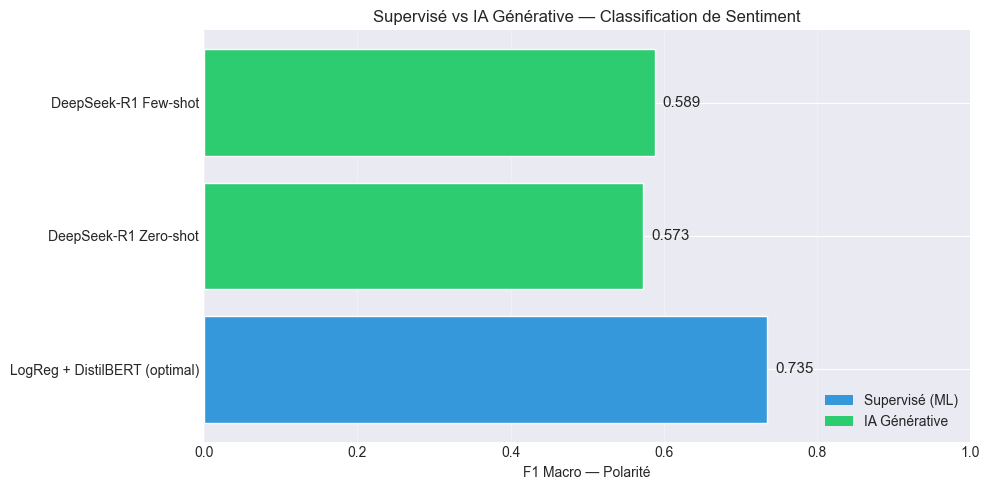

In [13]:
# Graphique comparatif
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Supervisé (ML)': '#3498db', 'IA Générative': '#2ecc71'}
bars = ax.barh(comparison['Approche'], comparison['F1 Polarité'],
               color=[colors[t] for t in comparison['Type']], edgecolor='white')

ax.set_xlabel('F1 Macro — Polarité')
ax.set_title('Supervisé vs IA Générative — Classification de Sentiment')
ax.set_xlim(0, 1)

for bar, val in zip(bars, comparison['F1 Polarité']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=11)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=t) for t, c in colors.items()]
ax.legend(handles=legend_els, loc='lower right')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
save_figure('ia_gen_comparison.png', output_dir='../../outputs/figures')
plt.show()

---
## 7. Conclusion

In [14]:
print("=" * 60)
print("CONCLUSION — IA GÉNÉRATIVE POUR LA CLASSIFICATION")
print("=" * 60)

print(f"""
Modèle testé : DeepSeek-R1 8B (via Ollama, inférence locale)
Échantillon  : {len(df_sample)} avis (20 par classe)

PERFORMANCES :
  Zero-shot : F1={f1_zs:.4f} | Accuracy={acc_zs:.4f}
  Few-shot  : F1={f1_fs:.4f} | Accuracy={acc_fs:.4f}
  Meilleur supervisé : F1={best_f1:.4f} | Accuracy={best_acc:.4f}

AVANTAGES :
  - Aucun entraînement nécessaire (zero-shot)
  - Analyse d'aspects (ABSA) sans données annotées
  - Explications en langage naturel
  - Adaptable sans re-entraînement

LIMITES :
  - Temps d'inférence élevé (~{total_time_fs/len(texts):.0f}s/avis vs <1ms pour ML)
  - Performances inférieures aux modèles supervisés
  - Variabilité des réponses (format non garanti)

VERDICT :
  IA générative = excellente pour l'analyse qualitative (ABSA)
  mais en retrait pour la classification quantitative face
  aux modèles supervisés entraînés sur le domaine.
""")

CONCLUSION — IA GÉNÉRATIVE POUR LA CLASSIFICATION

Modèle testé : DeepSeek-R1 8B (via Ollama, inférence locale)
Échantillon  : 60 avis (20 par classe)

PERFORMANCES :
  Zero-shot : F1=0.5732 | Accuracy=0.6833
  Few-shot  : F1=0.5887 | Accuracy=0.6724
  Meilleur supervisé : F1=0.7351 | Accuracy=0.8780

AVANTAGES :
  - Aucun entraînement nécessaire (zero-shot)
  - Analyse d'aspects (ABSA) sans données annotées
  - Explications en langage naturel
  - Adaptable sans re-entraînement

LIMITES :
  - Temps d'inférence élevé (~26s/avis vs <1ms pour ML)
  - Performances inférieures aux modèles supervisés
  - Variabilité des réponses (format non garanti)

VERDICT :
  IA générative = excellente pour l'analyse qualitative (ABSA)
  mais en retrait pour la classification quantitative face
  aux modèles supervisés entraînés sur le domaine.

